In [2]:
from bs4 import BeautifulSoup
import requests

Reading html

In [3]:
# URL of the Wikipedia page containing the list of largest companies in India
url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_India"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36"
}

page = requests.get(url, headers=headers)
soup = BeautifulSoup(page.text, "html.parser")

print(soup)

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of largest companies in India - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-

In [4]:
html_table = soup.find_all("table")[0]

In [5]:
html_titles =html_table.find_all("th")

In [6]:
# extracting column titles
titles = [title.text.strip() for title in html_titles]

In [7]:
titles

['Rank',
 'Forbes 2000 rank',
 'Name',
 'Headquarters',
 'Revenue(billions US$)',
 'Profit(billions US$)',
 'Assets(billions US$)',
 'Value(billions US$)',
 'Industry']

In [8]:
import pandas as pd

In [9]:
df = pd.DataFrame(columns=titles)
df

,Rank,Forbes 2000 rank,Name,Headquarters,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry


In [10]:
column_data = html_table.find_all("tr")

In [11]:
# extracting data from each row and adding it to the dataframe
for row  in column_data[1:]:
    row_data = row.find_all("td")
    individual_row = [data.text.strip() for data in row_data]
    # print(individual_row)
    df.loc[len(df)] = individual_row

In [27]:
df #final dataframe

,Rank,Forbes 2000 rank,Name,Headquarters,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry
0,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate
1,2,55,State Bank of India,Mumbai,71.8,8.1,807.4,87.6,Banking
2,3,65,HDFC Bank,Mumbai,49.3,7.7,483.2,133.6,Banking
3,4,70,Life Insurance Corporation,New Delhi,98.0,4.9,561.4,73.6,Insurance
4,5,142,ICICI Bank,Mumbai,28.5,5.3,283.5,95.3,Banking
...,...,...,...,...,...,...,...,...,...
66,65,1895,Dr. Reddy's Laboratories,Hyderabad,3.4,0.7,4.6,11.6,Pharmaceuticals
67,66,1908,Varun Beverages,Gurgaon,2.0,0.3,1.8,23.6,Beverages
68,67,1949,CIFCL,Chennai,2.3,0.4,18.8,13.0,Financials
69,68,1957,NMDC,Hyderabad,2.5,0.8,3.9,9.7,Mining


In [13]:
df.to_csv("largest_companies_in_india.csv", index=False) #save as csv

In [ ]:
df = df.rename(columns={
    'Revenue(billions US$)': 'Revenue',
    'Profit(billions US$)': 'Profit',
    'Assets(billions US$)': 'Assets',
    'Value(billions US$)': 'Value'
})

df = df.dropna()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 0 to 70
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              71 non-null     object 
 1   Forbes 2000 rank  71 non-null     object 
 2   Name              71 non-null     object 
 3   Headquarters      71 non-null     object 
 4   Revenue           71 non-null     float64
 5   Profit            71 non-null     object 
 6   Assets            71 non-null     object 
 7   Value             71 non-null     object 
 8   Industry          71 non-null     object 
dtypes: float64(1), object(8)
memory usage: 5.5+ KB


In [ ]:
cols = ['Revenue','Profit','Assets','Value']

for col in cols:
    df[col] = (
        df[col]
        .astype(str)  # ensure string
        .str.replace('−', '-', regex=False)  
        .str.replace(',', '', regex=False)
        .str.replace(r'[^0-9.\-]', '', regex=True)  
    )
    
    df[col] = pd.to_numeric(df[col], errors='coerce') 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 0 to 70
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              71 non-null     object 
 1   Forbes 2000 rank  71 non-null     object 
 2   Name              71 non-null     object 
 3   Headquarters      71 non-null     object 
 4   Revenue           71 non-null     float64
 5   Profit            71 non-null     float64
 6   Assets            71 non-null     float64
 7   Value             71 non-null     float64
 8   Industry          71 non-null     object 
dtypes: float64(4), object(5)
memory usage: 5.5+ KB


In [41]:
df.describe()

,Revenue,Profit,Assets,Value
count,71.000000,71.000000,71.000000,71.000000
mean,17.812676,1.697183,71.621127,33.588732
std,23.347499,1.930283,132.730041,37.901853
min,0.200000,-0.400000,1.300000,1.100000
25%,4.150000,0.500000,10.550000,12.000000
50%,10.800000,0.900000,27.400000,23.600000
75%,17.750000,2.250000,58.200000,39.000000
max,108.800000,8.400000,807.400000,233.100000


In [45]:
#sort by Revenue and display top 10 companies
top10 = df.sort_values(by='Revenue', ascending=False).head(10)
top10


,Rank,Forbes 2000 rank,Name,Headquarters,Revenue,Profit,Assets,Value,Industry
0,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate
3,4,70,Life Insurance Corporation,New Delhi,98.0,4.9,561.4,73.6,Insurance
6,7,259,Indian Oil Corporation,New Delhi,93.8,5.0,57.8,27.8,Oil and gas
5,6,207,Oil and Natural Gas Corporation,New Delhi,77.5,5.1,80.6,41.9,Oil and gas
1,2,55,State Bank of India,Mumbai,71.8,8.1,807.4,87.6,Banking
18,19,537,Bharat Petroleum,Mumbai,54.1,3.2,24.3,16.4,Oil and gas
7,8,284,Tata Motors,Mumbai,52.9,3.8,44.4,43.8,Automotive
2,3,65,HDFC Bank,Mumbai,49.3,7.7,483.2,133.6,Banking
50,49,1568,Rajesh Exports,Bangalore,32.6,0.1,4.1,2.0,Gems and jewellery
11,12,412,Tata Consultancy Services,Mumbai,29.1,5.5,17.6,166.5,Infotech


In [49]:
# Analyze the distribution of companies by industry
industry_counts = df['Industry'].value_counts()
industry_counts

Industry
Banking                  17
Financials                7
Oil and gas               4
Automotive                4
Infotech                  4
Iron and steel            4
Utilities                 3
Metals and mining         3
Pharmaceuticals           2
Insurance                 2
Capital goods             2
Telecommunication         2
Gems and jewellery        2
Holding                   2
Renewable energy          1
Aerospace and defense     1
Conglomerate              1
Real estate               1
Beverages                 1
Retail                    1
Consumer goods            1
Chemicals                 1
Shipping                  1
Airline                   1
Energy                    1
Diversified               1
Mining                    1
Name: count, dtype: int64

In [42]:
# Analyze the correlation between Revenue and Profit 
df[['Revenue','Profit']].corr()

,Revenue,Profit
Revenue,1.000000,0.796867
Profit,0.796867,1.000000


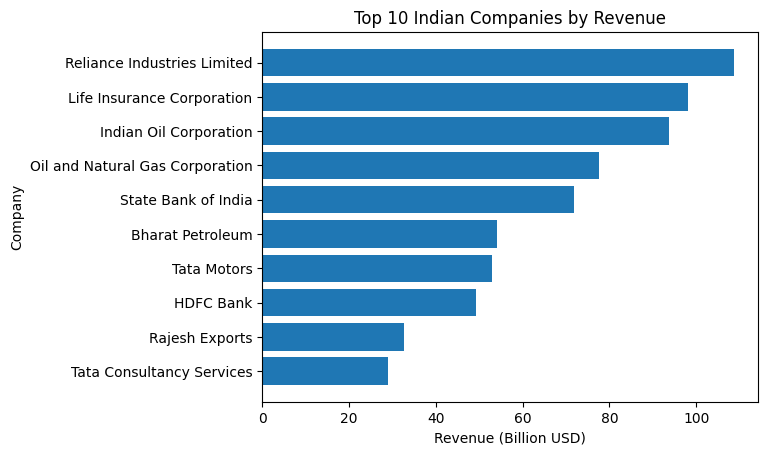

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.barh(top10['Name'], top10['Revenue']) # visualize top 10 companies by revenue

plt.xlabel("Revenue (Billion USD)")
plt.ylabel("Company")

plt.title("Top 10 Indian Companies by Revenue")

plt.gca().invert_yaxis()

plt.show() 

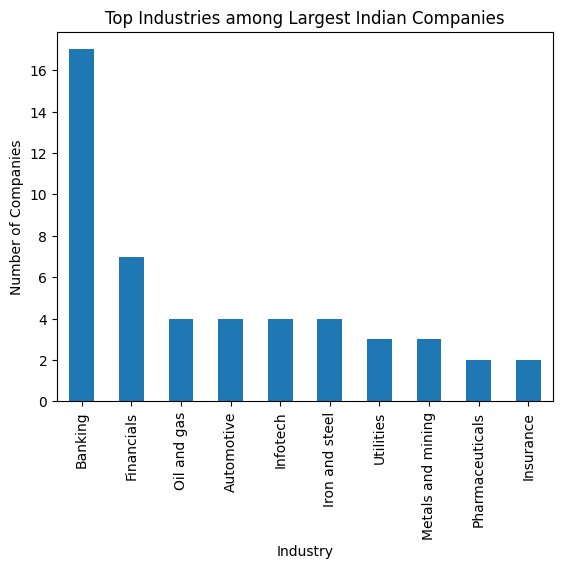

In [ ]:
plt.figure()

industry_counts.head(10).plot(kind='bar') # visualize top 10 industries by number of companies

plt.title("Top Industries among Largest Indian Companies")

plt.xlabel("Industry")
plt.ylabel("Number of Companies")

plt.show()

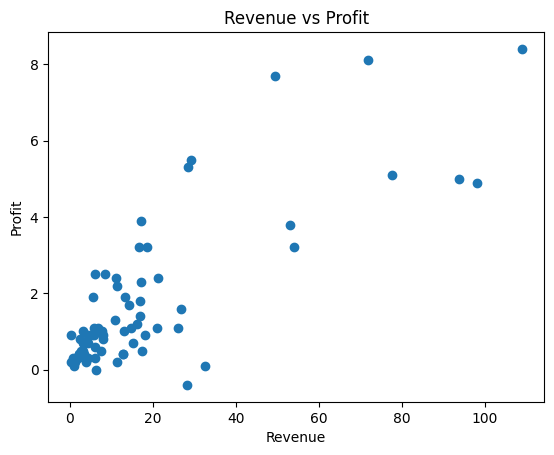

In [ ]:
plt.figure()

plt.scatter(df['Revenue'], df['Profit']) # visualize correlation between Revenue and Profit

plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.title("Revenue vs Profit")

plt.show()

Which company has the highest profit margin (Profit/Revenue)?

In [ ]:
df['ProfitMargin'] = (df['Profit'] / df['Revenue']) * 100
top_margin = df.sort_values(by='ProfitMargin', ascending=False).head(10)

top_margin[['Name', 'ProfitMargin']]

,Name,ProfitMargin
55,Bajaj Holdings & Investment,450.000000
49,Jio Financial Services,100.000000
37,Adani Power,40.983607
65,DLF,37.500000
29,Power Grid Corporation of India,33.928571
69,NMDC,32.000000
42,Adani Ports & SEZ,31.250000
28,ITC Limited,29.411765
15,Coal India,22.674419
32,Indian Railway Finance Corporation,21.875000


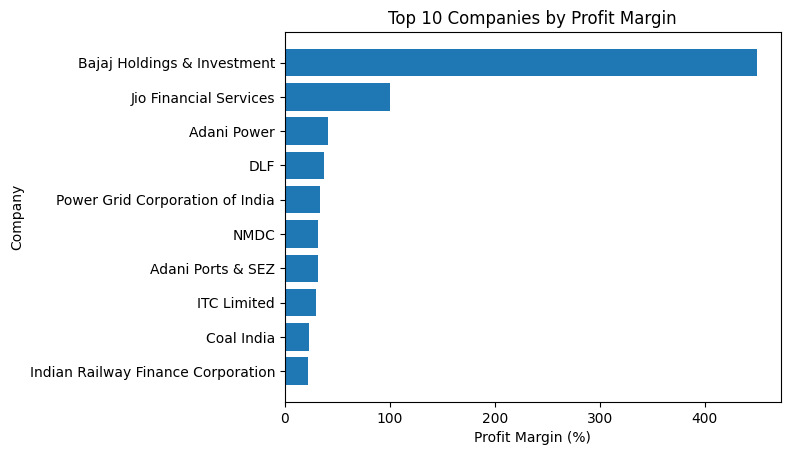

In [53]:
#visualize top 10 companies by profit margin
plt.figure()
plt.barh(top_margin['Name'], top_margin['ProfitMargin'])

plt.xlabel("Profit Margin (%)")
plt.ylabel("Company")
plt.title("Top 10 Companies by Profit Margin")

plt.gca().invert_yaxis()
plt.show()

How well do companies use their assets?

In [54]:
df['AssetTurnover'] = df['Revenue'] / df['Assets']

top_asset = df.sort_values(by='AssetTurnover', ascending=False).head(10)

top_asset[['Name', 'AssetTurnover']]

,Name,AssetTurnover
50,Rajesh Exports,7.951220
48,Titan Company,2.695652
51,DMart,2.440000
18,Bharat Petroleum,2.226337
11,Tata Consultancy Services,1.653409
6,Indian Oil Corporation,1.622837
58,Motherson Sumi Systems,1.212766
46,Asian Paints,1.194444
7,Tata Motors,1.191441
44,Bajaj Auto,1.148936


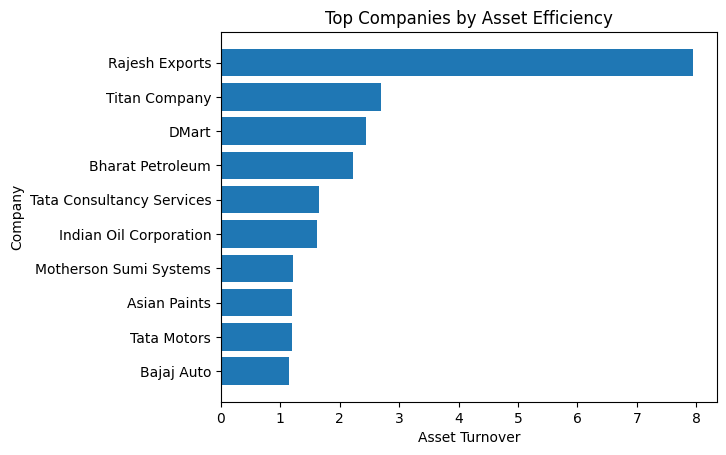

In [55]:
#visualize top 10 companies by asset turnover ratio
plt.figure()
plt.barh(top_asset['Name'], top_asset['AssetTurnover'])

plt.xlabel("Asset Turnover")
plt.ylabel("Company")
plt.title("Top Companies by Asset Efficiency")

plt.gca().invert_yaxis()
plt.show()

In [56]:
industry_analysis = df.groupby('Industry').agg({
    'Revenue': 'mean',
    'Profit': 'mean',
    'Name': 'count'
}).rename(columns={'Name': 'CompanyCount'})

industry_analysis.sort_values(by='Revenue', ascending=False).head(10)

,Revenue,Profit,CompanyCount
Industry,,,
Conglomerate,108.800000,8.400000,1
Oil and gas,60.375000,3.625000,4
Insurance,51.850000,2.900000,2
Automotive,21.625000,1.575000,4
Metals and mining,20.233333,1.833333,3
Gems and jewellery,19.400000,0.050000,2
Infotech,17.950000,2.975000,4
Iron and steel,17.075000,0.425000,4
Banking,16.547059,2.264706,17


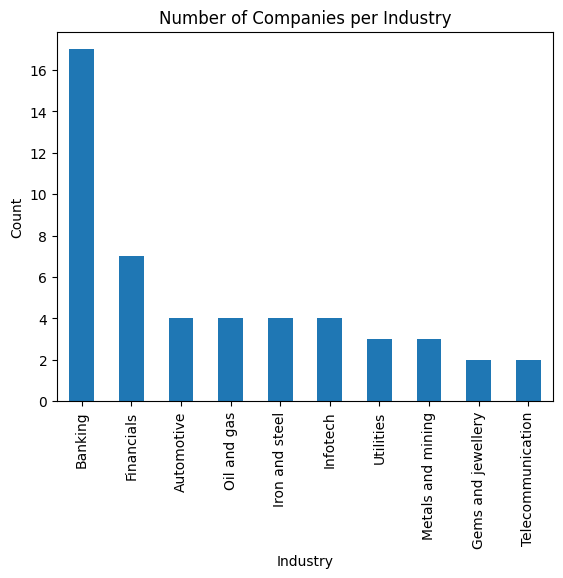

In [57]:
plt.figure()

industry_analysis['CompanyCount'].sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Number of Companies per Industry")
plt.xlabel("Industry")
plt.ylabel("Count")

plt.show()